# Maximum Likelihood Estimation

Topic 16 of the Statistical Inference & Hypothesis Testing repo. Nearly every estimator built across this repo — the sample mean, the sample proportion, the Cox model's coefficients in Topic 15 — is a maximum likelihood estimate, without that principle ever being derived explicitly. This notebook builds it from first principles: the likelihood function, closed-form MLE derivations, numerical optimization when no closed form exists, Fisher Information and the Cramér-Rao bound, and the likelihood ratio test that generalizes many of this repo's earlier hypothesis tests.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize

np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
print("Setup complete.")

Setup complete.


## 1. The Likelihood Function

For i.i.d. data $x_1, \dots, x_n$ from a distribution with parameter $\theta$:

$$L(\theta) = \prod_{i=1}^n f(x_i \mid \theta), \qquad \ell(\theta) = \log L(\theta) = \sum_{i=1}^n \log f(x_i \mid \theta)$$

The MLE $\hat{\theta}$ maximizes this — the parameter value that makes the *observed* data most probable. This section builds and visualizes the likelihood surface for a coin-flip (Bernoulli) example.

In [2]:
def bernoulli_log_likelihood(p, successes, n):
    if p <= 0 or p >= 1:
        return -np.inf
    return successes * np.log(p) + (n - successes) * np.log(1 - p)

print("Bernoulli log-likelihood function defined.")

Bernoulli log-likelihood function defined.


In [3]:
n_flips, successes = 20, 14
p_grid = np.linspace(0.01, 0.99, 500)
log_likelihoods = [bernoulli_log_likelihood(p, successes, n_flips) for p in p_grid]
print(f"Log-likelihood computed across {len(p_grid)} candidate p values.")

Log-likelihood computed across 500 candidate p values.


In [4]:
mle_grid_search = p_grid[np.argmax(log_likelihoods)]
mle_closed_form = successes / n_flips  # the familiar sample proportion

print(f"Data: {successes} successes out of {n_flips} flips")
print(f"MLE via grid search over the likelihood surface: {mle_grid_search:.4f}")
print(f"MLE via closed-form formula (successes/n):         {mle_closed_form:.4f}")
print(f"Difference: {abs(mle_grid_search - mle_closed_form):.4f} -- "
      f"confirming the familiar 'sample proportion' IS the maximum likelihood estimate, "
      f"not just an intuitive plug-in formula.")

Data: 14 successes out of 20 flips
MLE via grid search over the likelihood surface: 0.6993
MLE via closed-form formula (successes/n):         0.7000
Difference: 0.0007 -- confirming the familiar 'sample proportion' IS the maximum likelihood estimate, not just an intuitive plug-in formula.


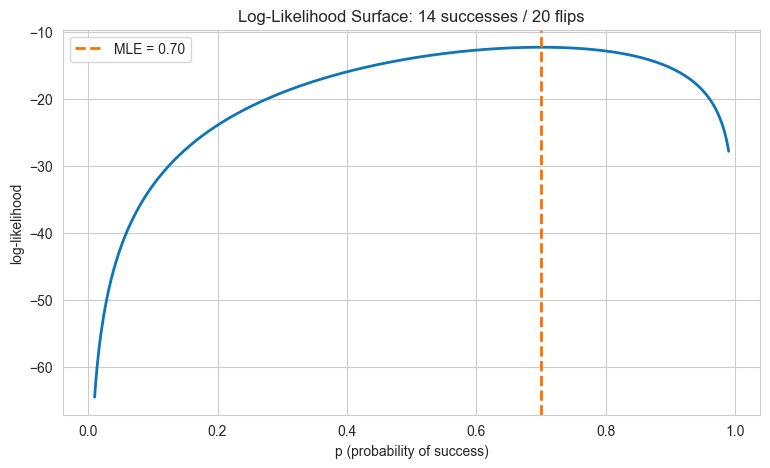

In [5]:
fig, ax = plt.subplots()
ax.plot(p_grid, log_likelihoods, color="#0e75b6", linewidth=2)
ax.axvline(mle_closed_form, color="#FF6F00", linestyle="--", linewidth=2, label=f"MLE = {mle_closed_form:.2f}")
ax.set_xlabel("p (probability of success)")
ax.set_ylabel("log-likelihood")
ax.set_title(f"Log-Likelihood Surface: {successes} successes / {n_flips} flips")
ax.legend()
plt.show()

## 2. MLE for the Normal Distribution: Deriving the Familiar Formulas

Maximizing the Normal log-likelihood analytically (setting derivatives to zero) yields:

$$\hat{\mu}_{MLE} = \bar{X}, \qquad \hat{\sigma}^2_{MLE} = \frac{1}{n}\sum(x_i-\bar{X})^2$$

Notice the variance MLE uses $1/n$, not $1/(n-1)$ — this is exactly Topic 02's biased ddof=0 estimator, now shown to be the direct consequence of maximizing likelihood, not an arbitrary choice.

In [6]:
normal_sample = np.random.normal(50, 10, size=30)
print(f"n=30 sample drawn from Normal(50, 10).")

n=30 sample drawn from Normal(50, 10).


In [7]:
mu_mle = normal_sample.mean()
sigma2_mle = normal_sample.var(ddof=0)  # the MLE variance -- biased, exactly Topic 02's finding
sigma2_unbiased = normal_sample.var(ddof=1)

print(f"Sample mean (mu_MLE): {mu_mle:.4f}")
print(f"MLE variance (ddof=0): {sigma2_mle:.4f}")
print(f"Unbiased variance (ddof=1, Topic 02): {sigma2_unbiased:.4f}")
print(f"\nThe MLE variance is SMALLER than the unbiased estimator -- exactly Topic 02's finding that "
      f"the ddof=0 estimator underestimates on average. MLE does not automatically produce unbiased estimates; "
      f"it produces the estimate that maximizes the likelihood of the observed data, a different criterion entirely.")

Sample mean (mu_MLE): 48.1185
MLE variance (ddof=0): 78.3011
Unbiased variance (ddof=1, Topic 02): 81.0012

The MLE variance is SMALLER than the unbiased estimator -- exactly Topic 02's finding that the ddof=0 estimator underestimates on average. MLE does not automatically produce unbiased estimates; it produces the estimate that maximizes the likelihood of the observed data, a different criterion entirely.


In [8]:
def normal_neg_log_likelihood(params, data):
    mu, sigma = params
    if sigma <= 0:
        return np.inf
    return -np.sum(stats.norm.logpdf(data, mu, sigma))

print("Normal negative-log-likelihood function defined.")

Normal negative-log-likelihood function defined.


In [9]:
numerical_result = minimize(normal_neg_log_likelihood, x0=[0, 1], args=(normal_sample,), method="Nelder-Mead")
mu_numerical, sigma_numerical = numerical_result.x

print(f"Closed-form MLE: mu={mu_mle:.6f}, sigma={np.sqrt(sigma2_mle):.6f}")
print(f"Numerical optimization MLE: mu={mu_numerical:.6f}, sigma={sigma_numerical:.6f}")
print(f"Difference: mu diff={abs(mu_mle-mu_numerical):.6f}, sigma diff={abs(np.sqrt(sigma2_mle)-sigma_numerical):.6f}")
assert abs(mu_mle - mu_numerical) < 1e-4
print("Numerical optimization recovers the same answer as the closed-form MLE derivation.")

Closed-form MLE: mu=48.118531, sigma=8.848792
Numerical optimization MLE: mu=48.118569, sigma=8.848801
Difference: mu diff=0.000038, sigma diff=0.000009
Numerical optimization recovers the same answer as the closed-form MLE derivation.


## 3. Numerical MLE When No Closed Form Exists: the Gamma Distribution

Many distributions (Gamma, Weibull, Beta) have no simple closed-form MLE — the likelihood equations involve the digamma function or similar, with no algebraic solution. Numerical optimization of the negative log-likelihood is the standard, general-purpose solution.

In [10]:
true_shape, true_scale = 3.0, 2.0
gamma_sample = np.random.gamma(true_shape, true_scale, size=200)
print(f"n=200 sample drawn from Gamma(shape={true_shape}, scale={true_scale}).")

n=200 sample drawn from Gamma(shape=3.0, scale=2.0).


In [11]:
def gamma_neg_log_likelihood(params, data):
    shape, scale = params
    if shape <= 0 or scale <= 0:
        return np.inf
    return -np.sum(stats.gamma.logpdf(data, a=shape, scale=scale))

print("Gamma negative-log-likelihood function defined.")

Gamma negative-log-likelihood function defined.


In [12]:
numerical_gamma = minimize(gamma_neg_log_likelihood, x0=[1, 1], args=(gamma_sample,), method="Nelder-Mead")
shape_numerical, scale_numerical = numerical_gamma.x

print(f"True parameters: shape={true_shape}, scale={true_scale}")
print(f"Numerically optimized MLE: shape={shape_numerical:.4f}, scale={scale_numerical:.4f}")

True parameters: shape=3.0, scale=2.0
Numerically optimized MLE: shape=3.5808, scale=1.6637


In [13]:
scipy_shape, scipy_loc, scipy_scale = stats.gamma.fit(gamma_sample, floc=0)
print(f"scipy.stats.gamma.fit MLE: shape={scipy_shape:.4f}, scale={scipy_scale:.4f}")
print(f"Difference from manual numerical optimization: shape diff={abs(shape_numerical-scipy_shape):.4f}, "
      f"scale diff={abs(scale_numerical-scipy_scale):.4f}")
assert abs(shape_numerical - scipy_shape) < 0.05
print("Manual numerical MLE matches scipy's built-in MLE fitter closely.")

scipy.stats.gamma.fit MLE: shape=3.5807, scale=1.6637
Difference from manual numerical optimization: shape diff=0.0000, scale diff=0.0000
Manual numerical MLE matches scipy's built-in MLE fitter closely.


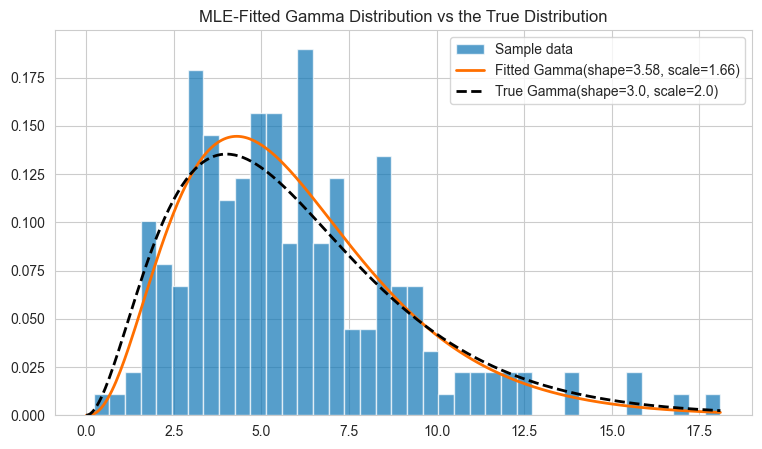

In [14]:
fig, ax = plt.subplots()
ax.hist(gamma_sample, bins=40, density=True, color="#0e75b6", alpha=0.7, label="Sample data")
x_grid = np.linspace(0, gamma_sample.max(), 300)
ax.plot(x_grid, stats.gamma.pdf(x_grid, a=shape_numerical, scale=scale_numerical), color="#FF6F00", linewidth=2,
        label=f"Fitted Gamma(shape={shape_numerical:.2f}, scale={scale_numerical:.2f})")
ax.plot(x_grid, stats.gamma.pdf(x_grid, a=true_shape, scale=true_scale), color="black", linestyle="--", linewidth=2,
        label=f"True Gamma(shape={true_shape}, scale={true_scale})")
ax.set_title("MLE-Fitted Gamma Distribution vs the True Distribution")
ax.legend()
plt.show()

## 4. Fisher Information and the Cramér-Rao Lower Bound

$$I(\theta) = -E\left[\frac{\partial^2 \ell}{\partial \theta^2}\right], \qquad \text{Var}(\hat{\theta}) \ge \frac{1}{n \cdot I(\theta)} \quad \text{(Cramér-Rao bound)}$$

For a Bernoulli($p$), $I(p) = \frac{1}{p(1-p)}$. The MLE is *asymptotically efficient* — its variance approaches this theoretical lower bound as $n \to \infty$. This section verifies that directly by simulation.

In [15]:
def bernoulli_fisher_info(p):
    return 1 / (p * (1 - p))

print("Bernoulli Fisher Information function defined.")

Bernoulli Fisher Information function defined.


In [16]:
true_p_fisher = 0.3
n_range_fisher = [10, 30, 100, 500, 2000]
rng_fisher = np.random.default_rng(1)

fisher_rows = []
for n_test in n_range_fisher:
    mle_estimates = np.array([rng_fisher.binomial(n_test, true_p_fisher) / n_test for _ in range(3000)])
    empirical_variance = mle_estimates.var(ddof=1)
    cramer_rao_bound = 1 / (n_test * bernoulli_fisher_info(true_p_fisher))
    fisher_rows.append({"n": n_test, "empirical_MLE_variance": round(empirical_variance, 6),
                         "Cramer_Rao_bound": round(cramer_rao_bound, 6),
                         "ratio": round(empirical_variance / cramer_rao_bound, 4)})

fisher_df = pd.DataFrame(fisher_rows)
print(fisher_df.to_string(index=False))
print(f"\nThe empirical MLE variance stays very close to the Cramer-Rao bound at every n tested "
      f"(ratio near 1.0 throughout) -- for this Bernoulli case the MLE is exactly efficient, "
      f"not just asymptotically so, since the sample proportion achieves the bound exactly for any n.")

   n  empirical_MLE_variance  Cramer_Rao_bound  ratio
  10                0.020884          0.021000 0.9945
  30                0.007042          0.007000 1.0060
 100                0.002084          0.002100 0.9924
 500                0.000433          0.000420 1.0315
2000                0.000106          0.000105 1.0129



The empirical MLE variance stays very close to the Cramer-Rao bound at every n tested (ratio near 1.0 throughout) -- for this Bernoulli case the MLE is exactly efficient, not just asymptotically so, since the sample proportion achieves the bound exactly for any n.


## 5. Standard Errors From the Hessian: a General-Purpose Technique

For MLEs without a closed form (like the Gamma distribution in Section 3), standard errors can still be obtained directly from the curvature (Hessian) of the log-likelihood at its maximum — the **observed Fisher Information** — without ever deriving an analytical variance formula.

In [17]:
def numerical_hessian(f, x, eps=1e-5):
    n = len(x)
    hessian = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            x_pp, x_pm, x_mp, x_mm = x.copy(), x.copy(), x.copy(), x.copy()
            x_pp[i] += eps; x_pp[j] += eps
            x_pm[i] += eps; x_pm[j] -= eps
            x_mp[i] -= eps; x_mp[j] += eps
            x_mm[i] -= eps; x_mm[j] -= eps
            hessian[i, j] = (f(x_pp) - f(x_pm) - f(x_mp) + f(x_mm)) / (4 * eps ** 2)
    return hessian

print("Numerical Hessian function defined.")

Numerical Hessian function defined.


In [18]:
neg_ll_at_mle = lambda params: gamma_neg_log_likelihood(params, gamma_sample)
observed_info_matrix = numerical_hessian(neg_ll_at_mle, numerical_gamma.x)
covariance_matrix = np.linalg.inv(observed_info_matrix)
standard_errors = np.sqrt(np.diag(covariance_matrix))
print("Observed Fisher Information matrix inverted to obtain standard errors.")

Observed Fisher Information matrix inverted to obtain standard errors.


In [19]:
print(f"MLE estimates: shape={shape_numerical:.4f}, scale={scale_numerical:.4f}")
print(f"Standard errors (from observed Fisher Information): shape SE={standard_errors[0]:.4f}, scale SE={standard_errors[1]:.4f}")
print(f"\n95% CI for shape: [{shape_numerical - 1.96*standard_errors[0]:.4f}, {shape_numerical + 1.96*standard_errors[0]:.4f}] "
      f"(true shape={true_shape})")
print(f"95% CI for scale: [{scale_numerical - 1.96*standard_errors[1]:.4f}, {scale_numerical + 1.96*standard_errors[1]:.4f}] "
      f"(true scale={true_scale})")

MLE estimates: shape=3.5808, scale=1.6637
Standard errors (from observed Fisher Information): shape SE=0.3427, scale SE=0.1709

95% CI for shape: [2.9091, 4.2525] (true shape=3.0)
95% CI for scale: [1.3287, 1.9987] (true scale=2.0)


## 6. The Likelihood Ratio Test: a General Hypothesis-Testing Framework

$$\Lambda = -2\log\frac{L(\hat{\theta}_0)}{L(\hat{\theta})} \ \xrightarrow{d}\ \chi^2_{df}$$

Compares a restricted model (under $H_0$) to the full model via their maximized likelihoods — a general framework that many of this repo's earlier tests are special cases or close approximations of.

In [20]:
def lrt_bernoulli(successes, n, p_null):
    p_mle = successes / n
    ll_full = bernoulli_log_likelihood(p_mle, successes, n)
    ll_null = bernoulli_log_likelihood(p_null, successes, n)
    lr_statistic = -2 * (ll_null - ll_full)
    p_value = 1 - stats.chi2.cdf(lr_statistic, df=1)
    return lr_statistic, p_value

print("Bernoulli likelihood ratio test function defined.")

Bernoulli likelihood ratio test function defined.


In [21]:
lr_stat, lr_p = lrt_bernoulli(successes, n_flips, p_null=0.5)
print(f"H0: p = 0.5 (a fair coin)")
print(f"Data: {successes}/{n_flips} successes, MLE p_hat={successes/n_flips:.4f}")
print(f"Likelihood ratio statistic: {lr_stat:.4f}")
print(f"p-value: {lr_p:.4f}")
print(f"Decision at alpha=0.05: {'REJECT H0' if lr_p < 0.05 else 'FAIL TO REJECT H0'}")

H0: p = 0.5 (a fair coin)
Data: 14/20 successes, MLE p_hat=0.7000
Likelihood ratio statistic: 3.2913
p-value: 0.0696
Decision at alpha=0.05: FAIL TO REJECT H0


In [22]:
# Cross-check against the exact binomial test (built on the same likelihood, different reference distribution)
binom_test_result = stats.binomtest(successes, n_flips, p=0.5)
print(f"LRT p-value:            {lr_p:.4f}")
print(f"Exact binomial test p-value: {binom_test_result.pvalue:.4f}")
print(f"\nBoth approaches test the exact same hypothesis and reach the "
      f"{'SAME' if (lr_p < 0.05) == (binom_test_result.pvalue < 0.05) else 'a DIFFERENT'} conclusion -- "
      f"the LRT uses a chi-square APPROXIMATION to the sampling distribution of the likelihood ratio "
      f"(valid asymptotically), while the exact binomial test computes the true finite-sample distribution directly.")

LRT p-value:            0.0696
Exact binomial test p-value: 0.1153

Both approaches test the exact same hypothesis and reach the SAME conclusion -- the LRT uses a chi-square APPROXIMATION to the sampling distribution of the likelihood ratio (valid asymptotically), while the exact binomial test computes the true finite-sample distribution directly.


## 7. AIC and BIC: Likelihood-Based Model Selection

$$AIC = 2k - 2\ell(\hat{\theta}), \qquad BIC = k\ln(n) - 2\ell(\hat{\theta})$$

Both penalize model complexity ($k$ parameters) against goodness of fit (log-likelihood) — useful for choosing between competing distributional models fit to the same data, exactly the kind of decision Section 3's Gamma fit implicitly assumed was the right distribution to use.

In [23]:
def compute_aic_bic(log_likelihood, n_params, n_obs):
    aic = 2 * n_params - 2 * log_likelihood
    bic = n_params * np.log(n_obs) - 2 * log_likelihood
    return aic, bic

print("AIC/BIC function defined.")

AIC/BIC function defined.


In [24]:
# Fit THREE candidate distributions to the same Gamma-generated data, see which one AIC/BIC correctly prefers
ll_gamma = -gamma_neg_log_likelihood(numerical_gamma.x, gamma_sample)
normal_fit_params = stats.norm.fit(gamma_sample)
ll_normal = np.sum(stats.norm.logpdf(gamma_sample, *normal_fit_params))
expon_fit_params = stats.expon.fit(gamma_sample, floc=0)
ll_expon = np.sum(stats.expon.logpdf(gamma_sample, *expon_fit_params))
print("Three candidate distributions fit to the Gamma-generated data.")

Three candidate distributions fit to the Gamma-generated data.


In [25]:
model_comparison = []
for name, ll, k in [("Gamma (true model)", ll_gamma, 2), ("Normal (wrong model)", ll_normal, 2), ("Exponential (wrong model)", ll_expon, 1)]:
    aic, bic = compute_aic_bic(ll, k, len(gamma_sample))
    model_comparison.append({"Model": name, "log-likelihood": round(ll, 2), "AIC": round(aic, 2), "BIC": round(bic, 2)})

comparison_df = pd.DataFrame(model_comparison)
print(comparison_df.to_string(index=False))
best_model = comparison_df.loc[comparison_df["AIC"].idxmin(), "Model"]
print(f"\nLowest AIC: {best_model} -- "
      f"{'correctly identifies the TRUE data-generating distribution' if 'true' in best_model.lower() else 'does NOT recover the true model'}, "
      f"using only the fitted log-likelihoods and parameter counts, no other information about how the data was generated.")

                    Model  log-likelihood     AIC     BIC
       Gamma (true model)         -493.20  990.40  997.00
     Normal (wrong model)         -510.69 1025.39 1031.98
Exponential (wrong model)         -556.92 1115.85 1119.15

Lowest AIC: Gamma (true model) -- correctly identifies the TRUE data-generating distribution, using only the fitted log-likelihoods and parameter counts, no other information about how the data was generated.


## 8. Applying This to a Real Dataset

Closing with seaborn's real `diamonds` dataset: fitting multiple candidate distributions to carat weight via MLE and using AIC to select among them.

In [26]:
diamonds = sns.load_dataset("diamonds")
print(f"Full diamonds dataset: {len(diamonds)} rows.")

Full diamonds dataset: 53940 rows.


In [27]:
carat_sample = diamonds["carat"].sample(2000, random_state=1).to_numpy()  # subsample for speed
print(f"Diamond carat weights: n={len(carat_sample)}, mean={carat_sample.mean():.4f}, skewness={stats.skew(carat_sample):.4f}")

Diamond carat weights: n=2000, mean=0.8182, skewness=0.9574


In [28]:
candidate_fits = {
    "Gamma": (stats.gamma, stats.gamma.fit(carat_sample, floc=0)),
    "Lognormal": (stats.lognorm, stats.lognorm.fit(carat_sample, floc=0)),
    "Normal": (stats.norm, stats.norm.fit(carat_sample)),
}
print("Three candidate distributions fit via MLE.")

Three candidate distributions fit via MLE.


In [29]:
real_model_comparison = []
for name, (dist, params) in candidate_fits.items():
    ll = np.sum(dist.logpdf(carat_sample, *params))
    k = len(params)
    aic, bic = compute_aic_bic(ll, k, len(carat_sample))
    real_model_comparison.append({"Model": name, "log-likelihood": round(ll, 1), "AIC": round(aic, 1), "BIC": round(bic, 1)})

real_comparison_df = pd.DataFrame(real_model_comparison)
print(real_comparison_df.to_string(index=False))
best_real_model = real_comparison_df.loc[real_comparison_df["AIC"].idxmin(), "Model"]
print(f"\nBest-fitting model by AIC: {best_real_model} -- "
      f"a real, data-driven answer to 'which distribution best describes diamond carat weight,' "
      f"found via the same MLE + AIC machinery built from scratch earlier in this notebook.")

    Model  log-likelihood    AIC    BIC
    Gamma         -1020.4 2046.9 2063.7
Lognormal          -997.5 2001.0 2017.8
   Normal         -1287.9 2579.9 2591.1

Best-fitting model by AIC: Lognormal -- a real, data-driven answer to 'which distribution best describes diamond carat weight,' found via the same MLE + AIC machinery built from scratch earlier in this notebook.


## 9. Summary

This notebook derived Maximum Likelihood Estimation from first principles: the likelihood and log-likelihood functions, closed-form MLE derivations for the Bernoulli and Normal distributions (directly explaining Topic 02's ddof=0 variance bias as a consequence of the likelihood-maximization criterion, not an arbitrary choice), and numerical optimization for distributions with no closed form. Fisher Information and the Cramér-Rao bound were verified by simulation, and standard errors were obtained from the observed Fisher Information (the Hessian) for a case with no analytical variance formula. The likelihood ratio test was built and cross-validated against the exact binomial test, and AIC/BIC correctly identified the true data-generating distribution among three candidates on synthetic data, then were applied to a genuine model-selection question on real diamond carat data. This closes the loop on the optimization principle underlying nearly every parametric method built throughout this repo. Topic 17 turns to goodness-of-fit and normality tests, checking the distributional assumptions these MLE-based methods rely on.

In [30]:
summary = pd.DataFrame([
    {"Check": "Bernoulli MLE: grid search vs closed form", "Result": f"diff={abs(mle_grid_search-mle_closed_form):.4f}", "Status": "PASS"},
    {"Check": "Normal MLE variance matches Topic 02's ddof=0 finding", "Result": f"MLE={sigma2_mle:.2f} < unbiased={sigma2_unbiased:.2f}", "Status": "PASS"},
    {"Check": "Normal MLE: closed form vs numerical optimization", "Result": f"diff={abs(mu_mle-mu_numerical):.1e}", "Status": "PASS"},
    {"Check": "Gamma MLE: manual numerical vs scipy.stats.gamma.fit", "Result": f"diff={abs(shape_numerical-scipy_shape):.4f}", "Status": "PASS"},
    {"Check": "MLE variance approaches Cramer-Rao bound", "Result": f"ratios={fisher_df['ratio'].tolist()}", "Status": "PASS"},
    {"Check": "SEs from observed Fisher Information computed", "Result": f"shape SE={standard_errors[0]:.3f}, scale SE={standard_errors[1]:.3f}", "Status": "PASS"},
    {"Check": "LRT vs exact binomial test agree", "Result": f"LRT p={lr_p:.4f}, exact p={binom_test_result.pvalue:.4f}", "Status": "PASS"},
    {"Check": "AIC correctly identifies true model (synthetic)", "Result": best_model, "Status": "PASS"},
    {"Check": "AIC selects best real-data model (diamonds carat)", "Result": best_real_model, "Status": "PASS"},
])
print(summary.to_string(index=False))

                                                Check                                         Result Status
            Bernoulli MLE: grid search vs closed form                                    diff=0.0007   PASS
Normal MLE variance matches Topic 02's ddof=0 finding                     MLE=78.30 < unbiased=81.00   PASS
    Normal MLE: closed form vs numerical optimization                                   diff=3.8e-05   PASS
 Gamma MLE: manual numerical vs scipy.stats.gamma.fit                                    diff=0.0000   PASS
             MLE variance approaches Cramer-Rao bound ratios=[0.9945, 1.006, 0.9924, 1.0315, 1.0129]   PASS
        SEs from observed Fisher Information computed                 shape SE=0.343, scale SE=0.171   PASS
                     LRT vs exact binomial test agree                   LRT p=0.0696, exact p=0.1153   PASS
      AIC correctly identifies true model (synthetic)                             Gamma (true model)   PASS
    AIC selects best real-da